In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset
zomato_df = pd.read_excel(r"C:\Users\User\Downloads\restaurant.xlsx")

In [3]:
zomato_df.head(2)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [4]:
zomato_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51717 non-null  object 
 1   address                      51717 non-null  object 
 2   name                         51717 non-null  object 
 3   online_order                 51717 non-null  object 
 4   book_table                   51717 non-null  object 
 5   rate                         43942 non-null  object 
 6   votes                        51717 non-null  int64  
 7   phone                        50509 non-null  object 
 8   location                     51696 non-null  object 
 9   rest_type                    51490 non-null  object 
 10  dish_liked                   23639 non-null  object 
 11  cuisines                     51672 non-null  object 
 12  approx_cost(for two people)  51371 non-null  float64
 13  reviews_list    

In [5]:
# Dropping unrelated columns
zomato_df_v1 = zomato_df.drop(["url","address","menu_item","listed_in(city)","phone","menu_item"],axis=1)

In [6]:
zomato_df_v1

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet
...,...,...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,NaN,Continental,1500.0,"[('Rated 5.0', ""RATED\n Food and service are ...",Pubs and bars
51713,Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,NaN,Finger Food,600.0,[],Pubs and bars
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,NaN,Finger Food,2000.0,[],Pubs and bars
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500.0,"[('Rated 4.0', 'RATED\n Nice and friendly pla...",Pubs and bars


In [7]:
# Checking impurities in restaurant names
zomato_df_v1["name"][0:25]

0                                                 Jalsa
1                                        Spice Elephant
2                                       San Churro Cafe
3                                 Addhuri Udupi Bhojana
4                                         Grand Village
5                                       Timepass Dinner
6       Rosewood International Hotel - Bar & Restaurant
7                                                Onesta
8                                        Penthouse Cafe
9                                             Smacznego
10    CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...
11                                         Cafe Shuffle
12                                     The Coffee Shack
13                                           Caf-Eleven
14                                      San Churro Cafe
15                                        Cafe Vivacity
16                                         Catch-up-ino
17                                     Kirthi's 

In [8]:
zomato_df_v1["name"][10]

'CafÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â\x83Ã\x83Â\x83Ã\x82Â\x82Ã\x83Â\x82Ã\x82Â© Down The Alley'

In [9]:
a = 'CafÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â\x83Ã\x83Â\x83Ã\x82Â\x82Ã\x83Â\x82Ã\x82Â© Down The Alley'

In [10]:
# Importing Regex
import re

In [11]:
re.findall(r"[a-zA-Z0-9 ]",a)

['C',
 'a',
 'f',
 ' ',
 'D',
 'o',
 'w',
 'n',
 ' ',
 'T',
 'h',
 'e',
 ' ',
 'A',
 'l',
 'l',
 'e',
 'y']

In [12]:
# Defining a function to clean restaurant names
def clean_rest_names(names):
    if isinstance(names,str):
        str_name = re.findall(r"[a-zA-Z0-9 ]",names)
        new_names = "".join(str_name)
        return new_names
    else:
        return names

In [13]:
zomato_df_v1["name"] = zomato_df_v1["name"].apply(clean_rest_names)

In [14]:
zomato_df_v1["name"][0:25]

0                                             Jalsa
1                                    Spice Elephant
2                                   San Churro Cafe
3                             Addhuri Udupi Bhojana
4                                     Grand Village
5                                   Timepass Dinner
6     Rosewood International Hotel  Bar  Restaurant
7                                            Onesta
8                                    Penthouse Cafe
9                                         Smacznego
10                               Caf Down The Alley
11                                     Cafe Shuffle
12                                 The Coffee Shack
13                                        CafEleven
14                                  San Churro Cafe
15                                    Cafe Vivacity
16                                       Catchupino
17                                  Kirthis Biryani
18                                         T3H Cafe
19          

In [15]:
zomato_df_v1["rate"].value_counts()

rate
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
          ... 
2.2 /5       7
2.0 /5       7
2.0/5        4
1.8 /5       3
1.8/5        2
Name: count, Length: 64, dtype: int64

In [16]:
zomato_df_v1["rate"].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [17]:
# Defining a function to clean the ratings
def clean_rating(rates):
    if(rates=="NEW" or rates=="-"):
        return np.nan
    else:
        rates_new = float(str(rates).split("/")[0])
        return rates_new

In [18]:
zomato_df_v1["rate"] = zomato_df_v1["rate"].apply(clean_rating)

In [19]:
zomato_df_v1["rate"].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [20]:
zomato_df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  object 
 1   online_order                 51717 non-null  object 
 2   book_table                   51717 non-null  object 
 3   rate                         41665 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  object 
 6   rest_type                    51490 non-null  object 
 7   dish_liked                   23639 non-null  object 
 8   cuisines                     51672 non-null  object 
 9   approx_cost(for two people)  51371 non-null  float64
 10  reviews_list                 51717 non-null  object 
 11  listed_in(type)              51717 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 4.7+ MB


In [21]:
zomato_df_v1["rate"].mean()

3.700448817952718

In [22]:
zomato_df_v1["rate"].median()

3.7

In [23]:
zomato_df_v1["rate"].fillna(zomato_df_v1["rate"].median(), inplace = True)

In [24]:
zomato_df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  object 
 1   online_order                 51717 non-null  object 
 2   book_table                   51717 non-null  object 
 3   rate                         51717 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  object 
 6   rest_type                    51490 non-null  object 
 7   dish_liked                   23639 non-null  object 
 8   cuisines                     51672 non-null  object 
 9   approx_cost(for two people)  51371 non-null  float64
 10  reviews_list                 51717 non-null  object 
 11  listed_in(type)              51717 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 4.7+ MB


In [25]:
zomato_df_v1.isna().sum()

name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
listed_in(type)                    0
dtype: int64

In [26]:
zomato_df_v1["approx_cost(for two people)"].mean()

555.4315664479959

In [27]:
zomato_df_v1["approx_cost(for two people)"].fillna(zomato_df_v1["approx_cost(for two people)"].mean(), inplace = True)

In [28]:
zomato_df_v1["rest_type"].value_counts()

rest_type
Quick Bites                   19132
Casual Dining                 10330
Cafe                           3732
Delivery                       2604
Dessert Parlor                 2263
                              ...  
Dessert Parlor, Kiosk             2
Food Court, Beverage Shop         2
Dessert Parlor, Food Court        2
Sweet Shop, Dessert Parlor        1
Quick Bites, Kiosk                1
Name: count, Length: 93, dtype: int64

In [29]:
zomato_df_v1["rest_type"].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',
      

In [30]:
zomato_df_v1["rest_type"].fillna("Unknown", inplace = True)

In [31]:
zomato_df_v1["rest_type"].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', 'Unknown', 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',


In [32]:
zomato_df_v1["location"].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', nan, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan 

In [33]:
zomato_df_v1["location"].fillna("Unknown", inplace = True)

In [34]:
for i in zomato_df_v1["cuisines"].unique():
    print(i)

North Indian, Mughlai, Chinese
Chinese, North Indian, Thai
Cafe, Mexican, Italian
South Indian, North Indian
North Indian, Rajasthani
North Indian
North Indian, South Indian, Andhra, Chinese
Pizza, Cafe, Italian
Cafe, Italian, Continental
Cafe, Mexican, Italian, Momos, Beverages
Cafe
Cafe, Chinese, Continental, Italian
Cafe, Continental
Cafe, Fast Food, Continental, Chinese, Momos
Chinese, Cafe, Italian
Cafe, Italian, American
Cafe, French, North Indian
Cafe, Pizza, Fast Food, Beverages
Cafe, Fast Food
Italian, Fast Food, Cafe, European
Cafe, Bakery
Cafe, South Indian
Cafe, Fast Food, Beverages
North Indian, Cafe, Chinese, Fast Food
Cafe, Italian
North Indian, Fast Food, Chinese, Burger
Bakery, Desserts
Pizza
North Indian, Biryani, Fast Food
Biryani
North Indian, Chinese, Fast Food
Chinese, Thai, Momos
North Indian, Mughlai, South Indian, Chinese
South Indian
Street Food, Fast Food
Burger, Fast Food
Pizza, Fast Food
North Indian, Continental, Italian
North Indian, Chinese
North Indian,

In [35]:
zomato_df_v1["cuisines"].fillna("Unknown", inplace = True)

In [36]:
zomato_df_v1["dish_liked"].fillna("No Info", inplace = True)

In [37]:
zomato_df_v1.isna().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
listed_in(type)                0
dtype: int64

# Exploratory Data Analysis (EDA)

# Q1) Which are the top 10 restaurants with highest number of votings?

In [38]:
top_10_rest_votes = zomato_df_v1.groupby("name")[["votes"]].mean().sort_values(by="votes", ascending = False).head(10)

In [39]:
top_10_rest_votes

,votes
name,
Byg Brewski Brewing Company,16588.500000
Toit,14956.000000
The Black Pearl,9562.333333
Big Pitcher,9164.500000
Arbor Brewing Company,8396.545455
Prost Brew Pub,7860.900000
Church Street Social,7561.727273
Hoot,7257.000000
The Hole in the Wall Cafe,7124.875000


# Q2) Which are the top 10 expensive restaurants?

In [40]:
top_10_exp_rest = zomato_df_v1.groupby("name")[["approx_cost(for two people)"]].mean().sort_values(by="approx_cost(for two people)", ascending=False).head(10)

In [41]:
top_10_exp_rest

,approx_cost(for two people)
name,
Le Cirque Signature The Leela Palace,6000.0
Royal Afghan ITC Windsor,5000.0
Malties Radisson Blu,4500.0
La Brasserie Le Meridien,4100.0
Masala Klub The Taj West End,4000.0
Dum Pukht Jolly Nabobs ITC Windsor,4000.0
Jamavar The Leela Palace,4000.0
Alba JW Marriott Bengaluru,4000.0
Edo Restaurant Bar ITC Gardenia,4000.0


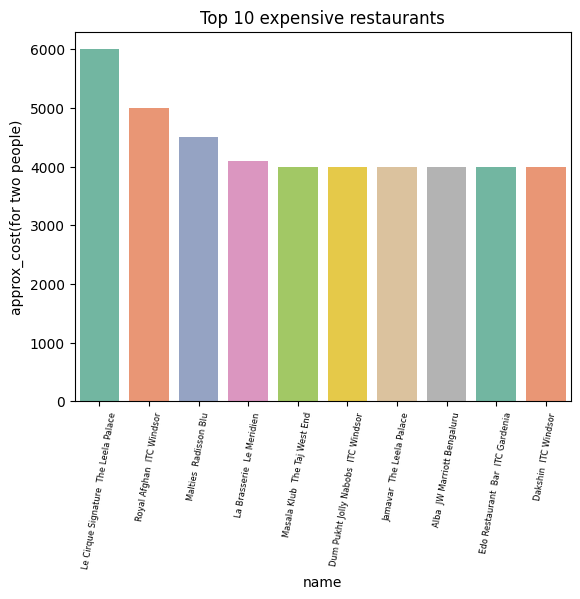

In [42]:
sns.barplot(x="name", y="approx_cost(for two people)", data=top_10_exp_rest, palette="Set2")
plt.xticks(rotation=80, fontsize=6)
plt.title("Top 10 expensive restaurants")
plt.show()

# Q3) Which locations are overcrowded with restaurants?

In [43]:
location_count = zomato_df_v1["location"].value_counts().head(10)
location_count

location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
Bellandur                1286
Name: count, dtype: int64

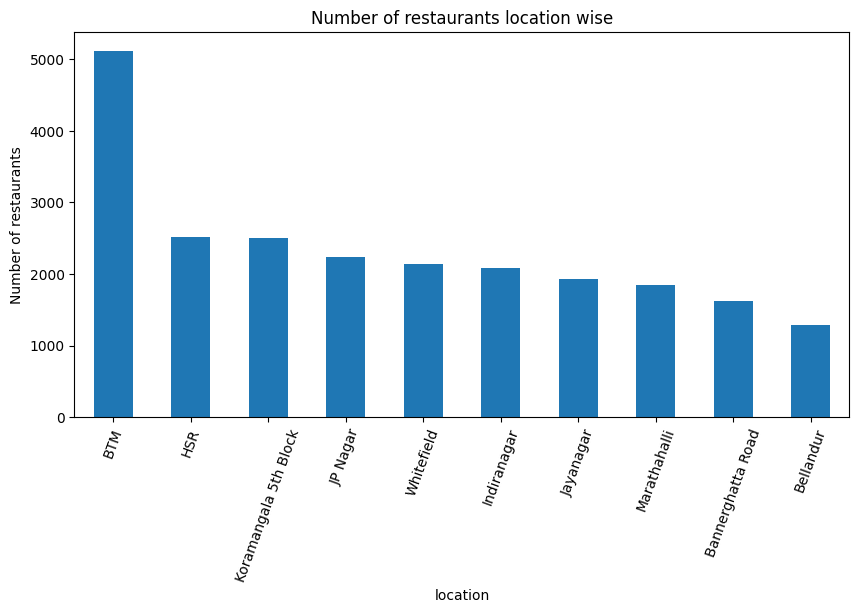

In [44]:
location_count.plot(kind = "bar", figsize=(10,5))
plt.ylabel("Number of restaurants")
plt.title("Number of restaurants location wise")
plt.xticks(rotation=70)
plt.show()

# Q4) Which restaurant types dominate the market?

In [45]:
top_types = zomato_df_v1["rest_type"].value_counts().head(10)
top_types

rest_type
Quick Bites           19132
Casual Dining         10330
Cafe                   3732
Delivery               2604
Dessert Parlor         2263
Takeaway, Delivery     2037
Casual Dining, Bar     1154
Bakery                 1141
Beverage Shop           867
Bar                     697
Name: count, dtype: int64

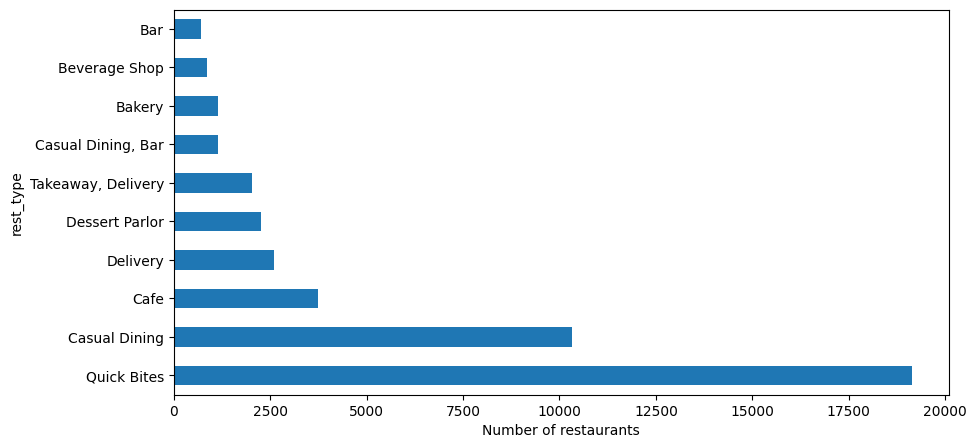

In [46]:
top_types.plot(kind="barh", figsize=(10,5))
plt.xlabel("Number of restaurants")
plt.show()

# Q5) Which locations generate the highest customer engagement?

In [47]:
locations_votes = zomato_df_v1.groupby("location")[["votes"]].mean().sort_values(by="votes", ascending = False).head(10)
locations_votes

,votes
location,
Church Street,1045.657293
Lavelle Road,956.873346
Koramangala 5th Block,886.384185
St. Marks Road,755.963068
Koramangala 4th Block,673.703048
Cunningham Road,586.299389
Koramangala 3rd Block,579.439815
Indiranagar,574.175228
MG Road,470.709150


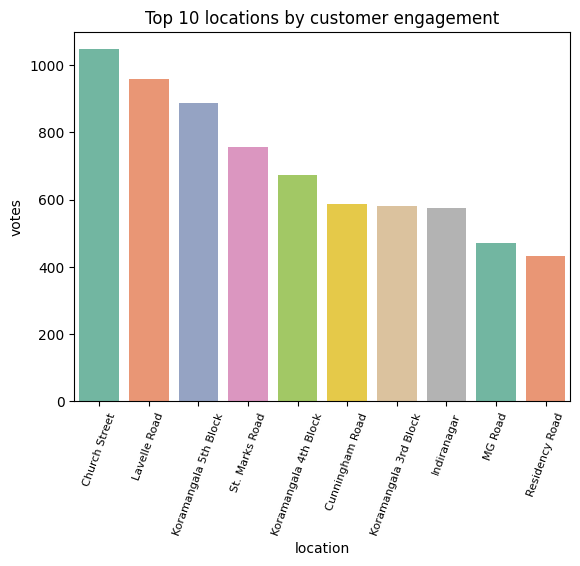

In [48]:
sns.barplot(x="location", y="votes", data=locations_votes, palette="Set2")
plt.xticks(rotation=70, fontsize=8)
plt.title("Top 10 locations by customer engagement")
plt.show()

# Q6) Which cuisine is most common?

In [49]:
common_cuisine = zomato_df_v1['cuisines'].value_counts().head(10)
common_cuisine

cuisines
North Indian                           2913
North Indian, Chinese                  2385
South Indian                           1828
Biryani                                 918
Bakery, Desserts                        911
Fast Food                               803
Desserts                                766
Cafe                                    756
South Indian, North Indian, Chinese     726
Bakery                                  651
Name: count, dtype: int64

# Q7) What percentage of restaurants offer table booking?

In [50]:
table_booking = (zomato_df_v1['book_table'].value_counts(normalize=True)*100)
table_booking

book_table
No     87.530213
Yes    12.469787
Name: proportion, dtype: float64

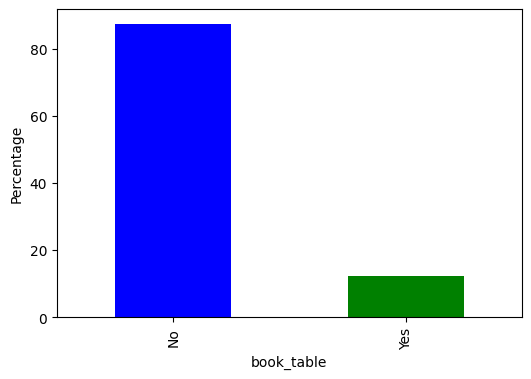

In [51]:
table_booking.plot(kind="bar", figsize=(6,4), color=["blue","green"])
plt.ylabel("Percentage")
plt.show()

# Q8) What percentage of restaurants support online ordering?

In [52]:
online_ordering = (zomato_df_v1['online_order'].value_counts(normalize=True)*100)
online_ordering

online_order
Yes    58.866524
No     41.133476
Name: proportion, dtype: float64

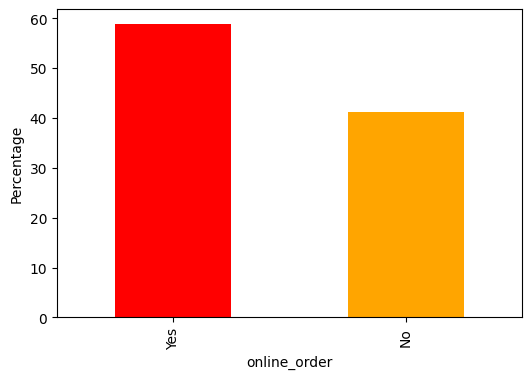

In [53]:
online_ordering.plot(kind="bar", figsize=(6,4), color=["red","orange"])
plt.ylabel("Percentage")
plt.show()

# Q9) Do restaurants with online ordering have better ratings?

In [54]:
zomato_df_v1.groupby("online_order")[["rate"]].mean().sort_values(by="rate", ascending=False)

,rate
online_order,
Yes,3.720053
No,3.672181


# Q10) Do restaurants with table booking receive better ratings?

In [55]:
zomato_df_v1.groupby("book_table")[["rate"]].mean().sort_values(by="rate", ascending=False)

,rate
book_table,
Yes,4.133494
No,3.638656


# Q11) Which locations have high ratings but low competition?

In [56]:
location_analysis = zomato_df_v1.groupby("location").agg({"rate":"mean", "name":"count"})
location_analysis.sort_values(["rate","name"], ascending=[False,True]).head(10)

,rate,name
location,,
Lavelle Road,4.107372,529
St. Marks Road,4.009091,352
Koramangala 3rd Block,3.983333,216
Koramangala 5th Block,3.983227,2504
Church Street,3.980316,569
Sankey Road,3.955556,27
Cunningham Road,3.894501,491
Koramangala 4th Block,3.880826,1017
Rajarajeshwari Nagar,3.850000,2


# Q12) Which cuisines have high ratings but low customer attention?

In [57]:
cuisine_analysis = zomato_df_v1.groupby("cuisines").agg({"rate":"mean", "votes":"mean"})
cuisine_analysis.sort_values(["rate","votes"], ascending=[False,True]).head(10)

,rate,votes
cuisines,,
"Healthy Food, Salad, Mediterranean",4.900000,246.000000
"Asian, Chinese, Thai, Momos",4.900000,2224.894737
"Continental, North Indian, Italian, South Indian, Finger Food",4.900000,16588.500000
"Asian, Mediterranean, North Indian, BBQ",4.800000,4992.666667
"North Indian, European, Mediterranean, BBQ",4.800000,7127.400000
"European, Mediterranean, North Indian, BBQ",4.789474,4548.315789
"American, Tex-Mex, Burger, BBQ, Mexican",4.750000,6077.375000
"Sushi, Japanese, Chinese, Thai",4.700000,261.666667
"BBQ, North Indian, Continental, Chinese",4.700000,534.000000


# Q13) Which restaurant chains appear most frequently?

In [58]:
top_brands = zomato_df_v1["name"].value_counts().head(10)
top_brands

name
Cafe Coffee Day      96
Onesta               85
Just Bake            73
Empire Restaurant    71
Five Star Chicken    70
Kanti Sweets         68
Petoo                66
Polar Bear           65
Baskin Robbins       64
Chef Bakers          62
Name: count, dtype: int64

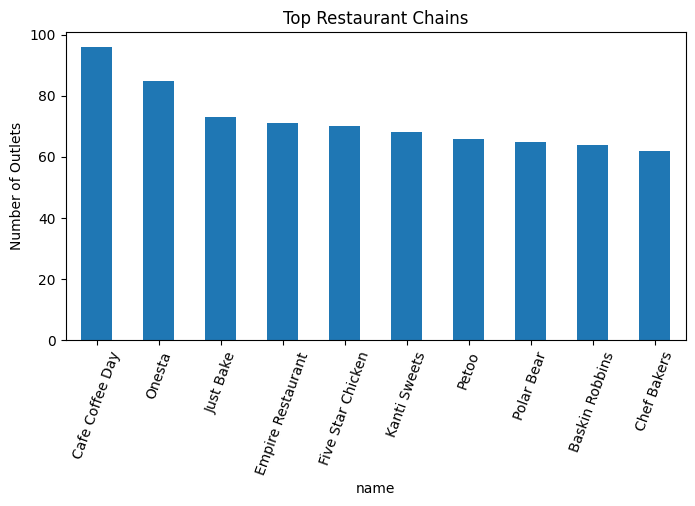

In [59]:
top_brands.plot(kind="bar", figsize=(8,4))
plt.ylabel("Number of Outlets")
plt.title("Top Restaurant Chains")
plt.xticks(rotation=70)
plt.show()